# Ejercicio 3 - Paralelismo local y medición de speedup

Objetivo: comparar una solución secuencial con una paralela local y medir speedup, eficiencia y overhead.
Este notebook implementa un ejemplo reproducible con un dataset sintético (>= 500000 registros).

## 1) Preparación: importaciones y generación del dataset

Generamos un dataset sintético con 500000 registros.

In [2]:
import time
import math
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# Semilla para reproducibilidad
rng = np.random.default_rng(42)
N = 500_000

df = pd.DataFrame({
    'user_id': rng.integers(1, 5000, size=N),
    'value': rng.standard_normal(N) * 100 + 1000,
    'category': rng.choice(list('ABCDE'), size=N),
    'text': rng.integers(0, 1<<20, size=N).astype(str)
})

df['timestamp'] = pd.date_range('2020-01-01', periods=N, freq='s')

df.head()

,user_id,value,category,text,timestamp
0,447,803.352581,A,131919,2020-01-01 00:00:00
1,3870,802.742785,C,11425,2020-01-01 00:00:01
2,3273,1120.160922,D,1031883,2020-01-01 00:00:02
3,2194,854.939980,E,750418,2020-01-01 00:00:03
4,2165,913.093180,B,5455,2020-01-01 00:00:04


## 2) Definir la tarea computacional repetible

Creamos una función que simula trabajo intensivo por fila (operaciones trigonométricas y hash),
para que la paralelización muestre impacto real sobre CPU.

In [3]:
def heavy_transform_record(rec):
    # rec es un dict para facilitar pickling entre procesos
    x = rec['value']
    s = 0.0
    for i in range(50):
        s += math.sin(x + i)**2 + math.cos(x * i + i)**2
    h = hashlib.sha256((rec['text'] + str(rec['user_id'])).encode()).hexdigest()
    return (rec['user_id'], rec['category'], s, h[:8])

# Versión ligera que usa apply de pandas (secuencial)
def heavy_transform_row(row):
    x = row['value']
    s = 0.0
    for i in range(50):
        s += math.sin(x + i)**2 + math.cos(x * i + i)**2
    h = hashlib.sha256((row['text'] + str(row['user_id'])).encode()).hexdigest()
    return pd.Series({'user_id': row['user_id'], 'category': row['category'], 'score': s, 'hash_prefix': h[:8]})

La versión paralela usa `joblib.Parallel` (backend `loky`) y mapea sobre una lista de dicts.
Observa que serializar muchos registros tiene overhead: lo analizaremos luego.

In [4]:
def run_sequential(df):
    start = time.perf_counter()
    res = df.apply(heavy_transform_row, axis=1, result_type='expand')
    t = time.perf_counter() - start
    return t, res

def run_parallel(records, workers, batch_size=1000):
    start = time.perf_counter()
    # Usamos joblib.Parallel con backend 'loky' para compatibilidad en Windows
    results = Parallel(n_jobs=workers, backend='loky', batch_size=batch_size)(
        delayed(heavy_transform_record)(rec) for rec in records
    )
    t = time.perf_counter() - start
    res_df = pd.DataFrame(results, columns=['user_id','category','score','hash_prefix'])
    return t, res_df

## 4) Ejecutar pruebas y medir tiempos

Ejecutaremos la versión secuencial como referencia (`p=1`) y la paralela con `p=2` y `p=4`.
Dependiendo del equipo, ejecutar esto puede tardar varios minutos.

In [5]:
# Convertir a lista de dicts para pasar a procesos hijo (serializable)
records = df.to_dict('records')

times = {}
# Ejecutar secuencial
print('Ejecutando versión secuencial...')
t1, res_seq = run_sequential(df)
times[1] = t1
print(f'Tiempo secuencial (p=1): {t1:.3f} s')

# Ejecutar paralela para p=2 y p=4
for p in (2, 4):
    print(f'Ejecutando versión paralela con p={p}...')
    tp, res_p = run_parallel(records, p)
    times[p] = tp
    print(f'Tiempo paralelo (p={p}): {tp:.3f} s')
    # liberar memoria
    del res_p

Ejecutando versión secuencial...
Tiempo secuencial (p=1): 90.816 s
Ejecutando versión paralela con p=2...
Tiempo paralelo (p=2): 8.154 s
Ejecutando versión paralela con p=4...
Tiempo paralelo (p=4): 4.462 s


In [6]:
# Tabla de tiempos, speedup y eficiencia
tbl = pd.DataFrame([{'p': p, 'time_s': times[p]} for p in sorted(times)])
T1 = times[1]
tbl['speedup'] = T1 / tbl['time_s']
tbl['efficiency'] = tbl['speedup'] / tbl['p']
tbl = tbl.set_index('p')
tbl

,time_s,speedup,efficiency
p,,,
1,90.815831,1.000000,1.000000
2,8.153621,11.138098,5.569049
4,4.462309,20.351758,5.087939


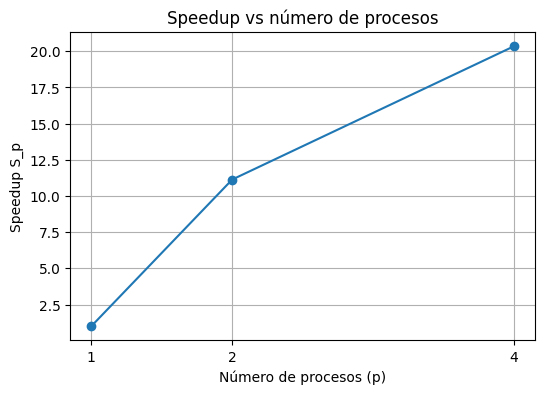

In [7]:
# Gráfico de speedup
plt.figure(figsize=(6,4))
plt.plot(tbl.index, tbl['speedup'], marker='o')
plt.title('Speedup vs número de procesos')
plt.xlabel('Número de procesos (p)')
plt.ylabel('Speedup S_p')
plt.xticks(tbl.index)
plt.grid(True)
plt.show()

## 5) Discusión breve

- Overhead de serialización: pasar `records` (lista de dicts) a procesos hijos implica copiar y serializar datos, lo que aumenta el tiempo para `p>1`.
- Granularidad de la tarea: elegimos una función relativamente costosa por fila para que la paralelización tenga sentido; si la función fuera ligera, el overhead dominaría.
- Particionamiento: usamos `map` con `chunksize` para agrupar tareas y reducir overhead. Para datasets muy grandes, es mejor procesar por chunks (lectura por lotes).
- Memoria compartida vs copia: aquí cada proceso recibe copias de los registros; usar memoria compartida (por ejemplo `shared_memory` o librerías como `dask`) puede reducir costos.
- Casos donde no mejora: si la tarea es I/O-bound o la sobrecarga de serializar y sincronizar es mayor que la ganancia en CPU, la paralelización local no aporta speedup.